## 1. Load Libraries

Import  Python packages.

For GPU runs, ensure CUDA is available.

In [1]:
import vapor
import scanpy as sc
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


## 2. Load Data and Preprocess

### 2.1 Preprocessing requirements
**VAPOR expects gene expression to be normalized and scaled**.
- Normalize gene expression (library size normalization + log1p is common)
- Select highly variable genes (optional but recommended)
- Scale features for stable optimization

In [2]:
import scvelo as scv

# Load pancreas dataset
adata = scv.datasets.pancreas()

# QC + filtering
scv.pp.filter_genes(adata, min_shared_counts=20)

# Normalize + log1p
scv.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)

# HVG selection
sc.pp.highly_variable_genes(adata, n_top_genes=5000)
adata = adata[:, adata.var['highly_variable']]

# Scale
sc.pp.scale(adata)

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### 2.2 PCA / UMAP: Initial Data Exploration

Before model training, we perform a low-dimensional embedding to obtain a coarse overview of the data structure and assess basic data quality.

This step enables:
- Inspect whether major cell populations or developmental stages are separable
- Check for obvious batch effects or technical artifacts

In [3]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [4]:
adata

AnnData object with n_obs × n_vars = 3696 × 5000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'highly_variable_genes', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'log1p', 'hvg', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

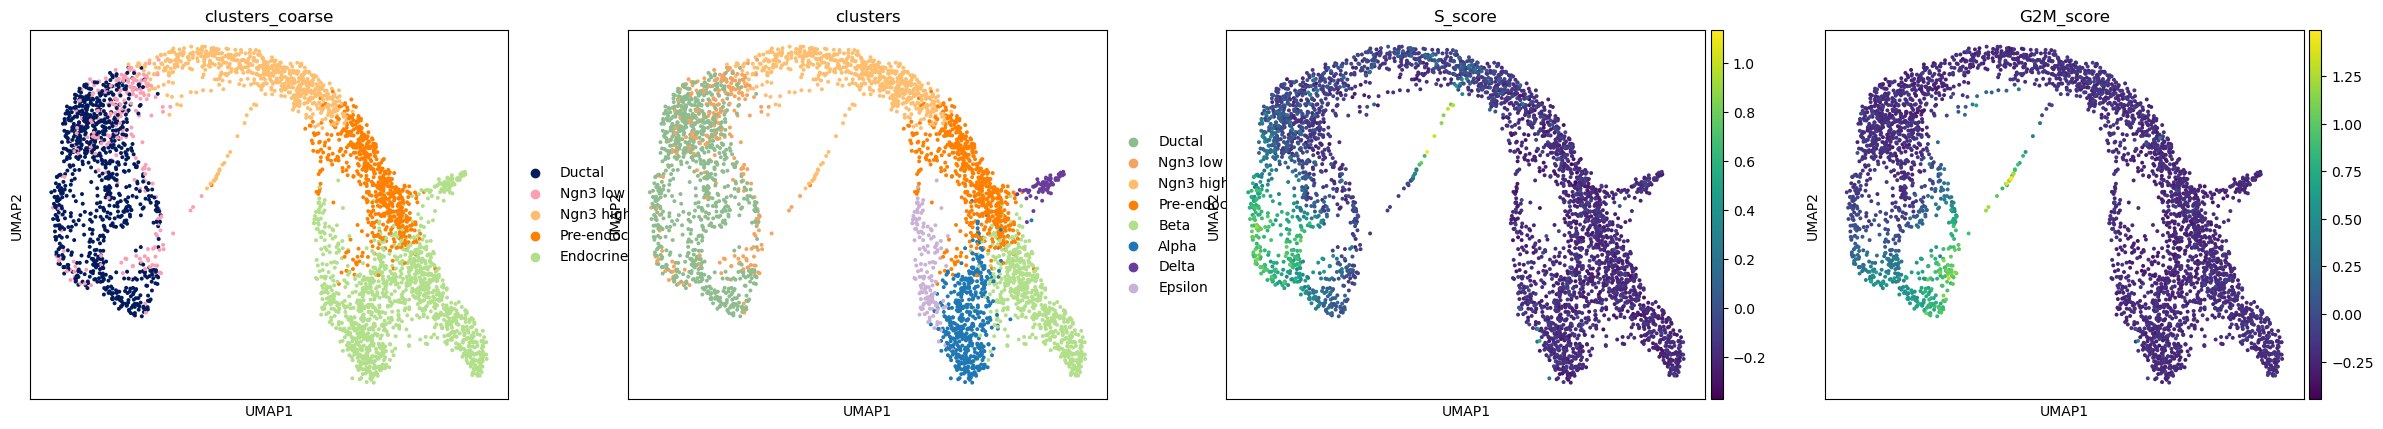

In [5]:
sc.pl.umap(adata,color=['clusters_coarse','clusters','S_score', 'G2M_score'])

## 3. Initialize Model and Train

### 3.1 Build Training Dataset

In [6]:
from vapor.dataset import select_obs_indices

root_cells, _ = select_obs_indices(
    adata, where={"clusters_coarse": "Ductal"}, n=100, seed=42
)
# terminal_cells, _ = select_obs_indices(
#     adata, where={"clusters_coarse": "Endocrine"}, n=100, seed=42
# )

dataset = vapor.dataset_from_adata(
    adata,
    root_indices=root_cells,
    terminal_indices=None,
    scale=True,
)

Data scaled per row.


### 3.2 Configure and Initialize Model

In [7]:
config = vapor.VAPORConfig(
    total_steps=20000,
    n_dynamics=10,
    lr=5e-5,
    beta=0.01,
    t_max=5,
    seed=0,
)

model = vapor.initialize_model(adata.n_vars, config=config)

Initializing model:
  Input dim: 5000
  Latent dim: 64
  Encoder dims: [2048, 512, 128]
  Decoder dims: [128, 512, 2048]
  N dynamics: 10


### 3.3 Train Model

[WARN] CUDA requested but not available. Falling back to CPU.


Training:   0%|          | 0/20000 [00:00<?, ?step/s]

Building initial graph...


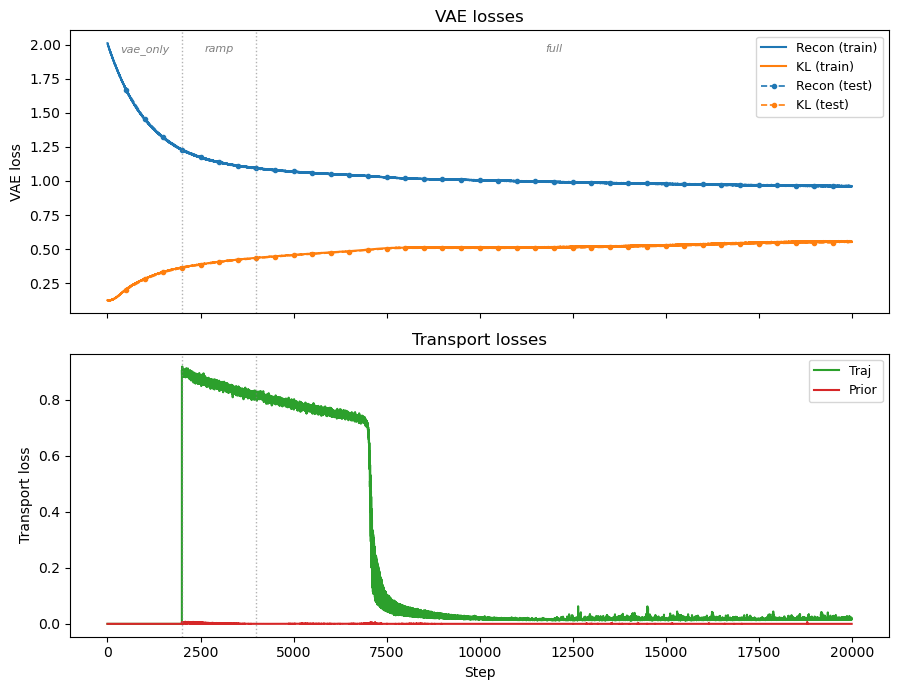

In [8]:
trained_model = vapor.train_model(model, dataset, config=config, verbose=True)

### 3.4 Save / Load Trained Model

In [9]:
# Save
vapor.save_checkpoint(trained_model, config, "pancreas_model.pt")

In [10]:
# Load
trained_model, ckpt = vapor.load_checkpoint("pancreas_model.pt")

Initializing model:
  Input dim: 5000
  Latent dim: 64
  Encoder dims: [2048, 512, 128]
  Decoder dims: [128, 512, 2048]
  N dynamics: 10


## 4. Downstream Inference

### 4.1 Extract Latent Representations and Dynamics

In [11]:
adata_VAPOR = vapor.extract_latents_and_dynamics(trained_model, adata, scale=True, device=device)

Using mu as the primary latent (X)


In [12]:
adata_VAPOR

AnnData object with n_obs × n_vars = 3696 × 64
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'pw_1', 'pw_2', 'pw_3', 'pw_4', 'pw_5', 'pw_6', 'pw_7', 'pw_8', 'pw_9', 'pw_10'
    uns: 'gene_names', 'n_dynamics'
    obsm: 'X_VAPOR', 'X_VAPOR_z', 'X_VAPOR_std', 'X_gex_pca', 'X_gex_umap'
    layers: 'v_psi1', 'v_psi2', 'v_psi3', 'v_psi4', 'v_psi5', 'v_psi6', 'v_psi7', 'v_psi8', 'v_psi9', 'v_psi10', 'v_VAPOR', 'vapor'

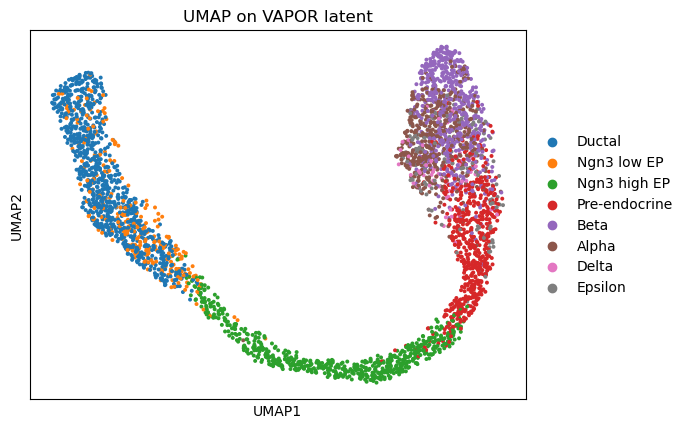

In [13]:
# UMAP on VAPOR latent (mu)
sc.pp.neighbors(adata_VAPOR, use_rep='X_VAPOR')
sc.tl.umap(adata_VAPOR)
sc.pl.umap(adata_VAPOR, color='clusters', title='UMAP on VAPOR latent')

### 4.2 Visualization

computing velocity graph (using 1/10 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'v_VAPOR_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'v_VAPOR_umap', embedded velocity vectors (adata.obsm)


/Users/jsheng/miniforge3/envs/VAPOR_env/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/jsheng/miniforge3/envs/VAPOR_env/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


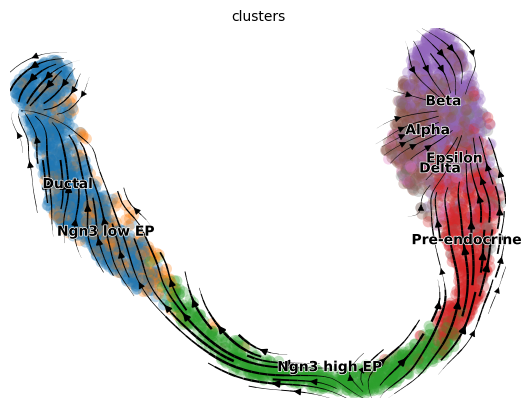

computing velocity embedding
    finished (0:00:00) --> added
    'v_VAPOR_gex_umap', embedded velocity vectors (adata.obsm)


/Users/jsheng/miniforge3/envs/VAPOR_env/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/jsheng/miniforge3/envs/VAPOR_env/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


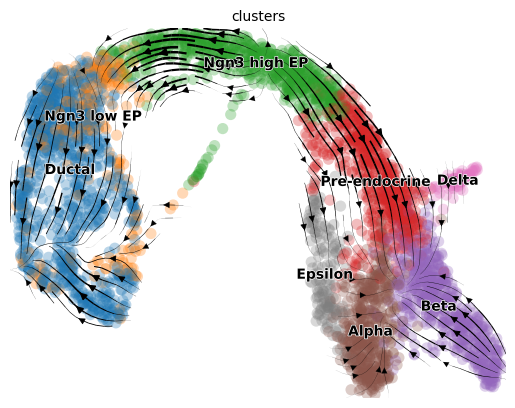

In [ ]:
# import scvelo as scv

# sc.pp.neighbors(adata_VAPOR, use_rep='X_VAPOR', n_neighbors=30)
# scv.tl.velocity_graph(adata_VAPOR, vkey='v_VAPOR', xkey='vapor')
# scv.pl.velocity_embedding_stream(adata_VAPOR, vkey='v_VAPOR', basis='umap', color='clusters')
# scv.pl.velocity_embedding_stream(adata_VAPOR, vkey='v_VAPOR', basis='gex_umap', color='clusters')

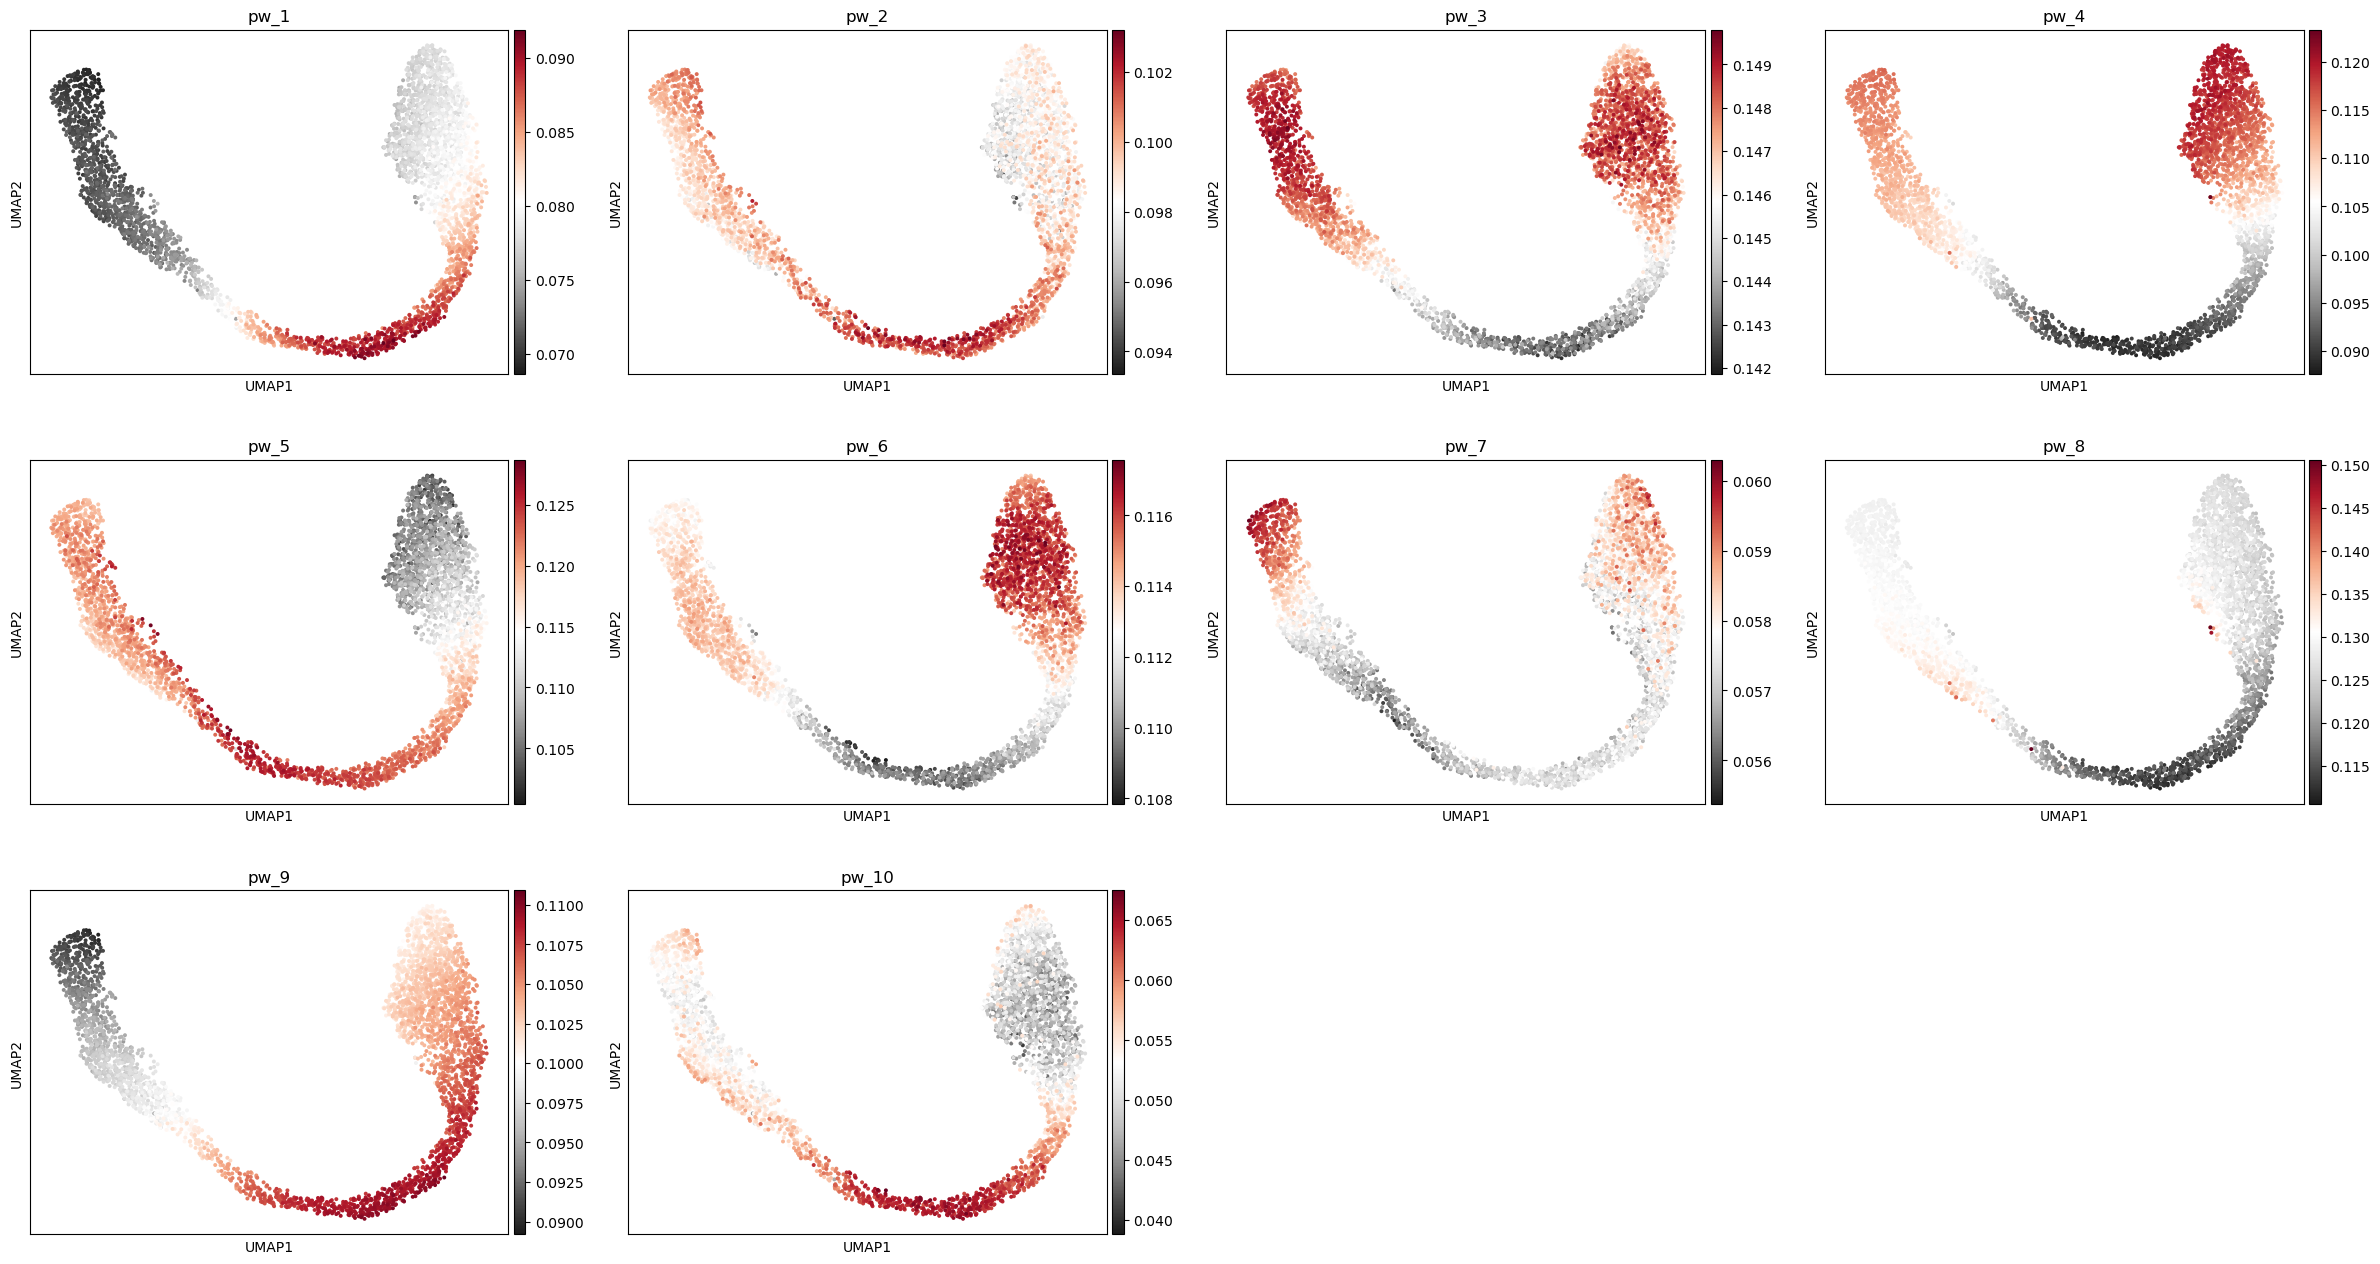

In [15]:
# Per-process gate weights
n_dynamics = trained_model.transport_op.n_dynamics
sc.pl.umap(
    adata_VAPOR,
    color=[f"pw_{i+1}" for i in range(n_dynamics)],
    cmap='RdGy_r',
)

### 4.3 Directional Gene Scoring and Enrichment

In [27]:
from vapor.inference import directional_gene_scores_jvp_progress, run_enrichment

adata_VAPOR = directional_gene_scores_jvp_progress(trained_model, adata_VAPOR, tau_quantile=0.6)

Directional gene scoring:   0%|          | 0/194 [00:00<?, ?it/s]

In [28]:
enrichment_results = run_enrichment(
    adata_VAPOR,
    select="pos",
    top_n=200,
    organism="Mouse",
    gene_sets=("GO_Biological_Process_2025", "GO_Cellular_Component_2025"),
)

Running enrichment for psi1_pos (200 genes) | feature_mode=gene
[RETRY 1/5] Error sending gene list, try again later ... sleep 3.4s
Running enrichment for psi2_pos (200 genes) | feature_mode=gene
Running enrichment for psi3_pos (200 genes) | feature_mode=gene
Running enrichment for psi4_pos (200 genes) | feature_mode=gene
Running enrichment for psi5_pos (200 genes) | feature_mode=gene
Running enrichment for psi6_pos (200 genes) | feature_mode=gene
Running enrichment for psi7_pos (200 genes) | feature_mode=gene
Running enrichment for psi8_pos (200 genes) | feature_mode=gene
[RETRY 1/5] Error sending gene list, try again later ... sleep 4.1s
Running enrichment for psi9_pos (200 genes) | feature_mode=gene
[RETRY 1/5] Error sending gene list, try again later ... sleep 3.9s
Running enrichment for psi10_pos (200 genes) | feature_mode=gene


Saved: heatmap_pos.pdf


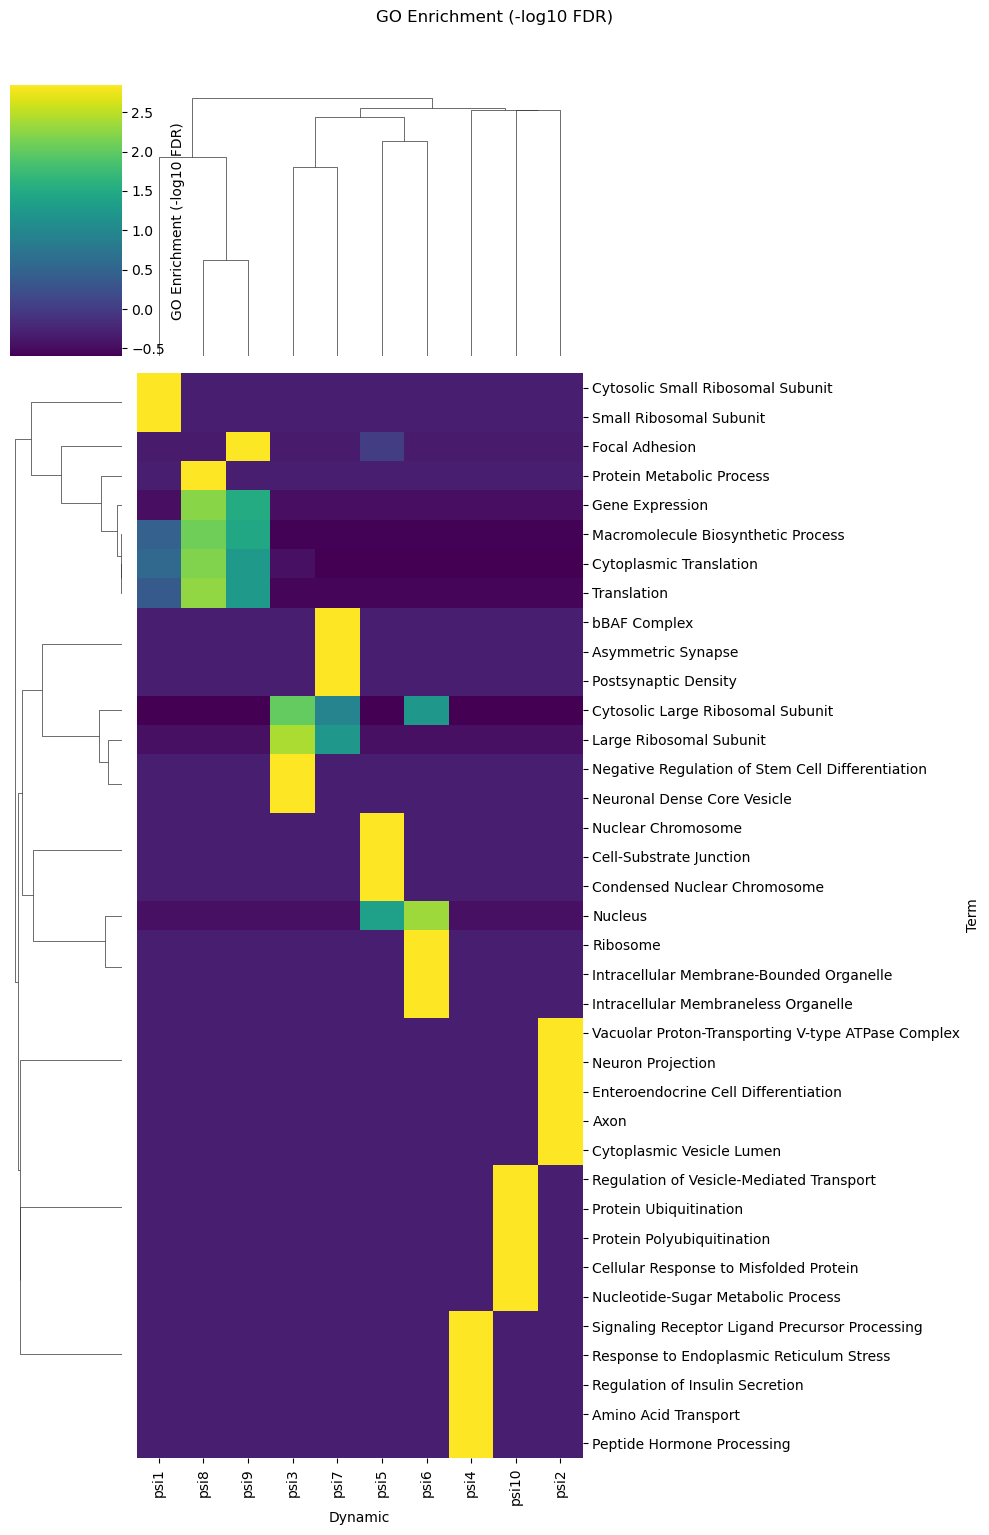

In [29]:
from vapor.inference import build_heatmap_mats, plot_heatmap

mat = build_heatmap_mats(enrichment_results, top_n=5)
for k, v in mat.items():
    plot_heatmap(v, 'GO Enrichment (-log10 FDR)',
                 figsize=(10, 15), cmap='viridis',
                 cluster=True, col_cluster=True, zscore_rows=True,
                 save=f"heatmap_{k}.pdf")

Running enrichment for psi1_pos (200 genes) | feature_mode=gene
Running enrichment for psi1_neg (200 genes) | feature_mode=gene
Running enrichment for psi2_pos (200 genes) | feature_mode=gene
Running enrichment for psi2_neg (200 genes) | feature_mode=gene
Running enrichment for psi3_pos (200 genes) | feature_mode=gene
Running enrichment for psi3_neg (200 genes) | feature_mode=gene
[RETRY 1/5] Error sending gene list, try again later ... sleep 3.4s
Running enrichment for psi4_pos (200 genes) | feature_mode=gene
Running enrichment for psi4_neg (200 genes) | feature_mode=gene
Running enrichment for psi5_pos (200 genes) | feature_mode=gene
Running enrichment for psi5_neg (200 genes) | feature_mode=gene
[RETRY 1/5] Error sending gene list, try again later ... sleep 4.4s
Running enrichment for psi6_pos (200 genes) | feature_mode=gene
Running enrichment for psi6_neg (200 genes) | feature_mode=gene
Running enrichment for psi7_pos (200 genes) | feature_mode=gene
Running enrichment for psi7_neg 

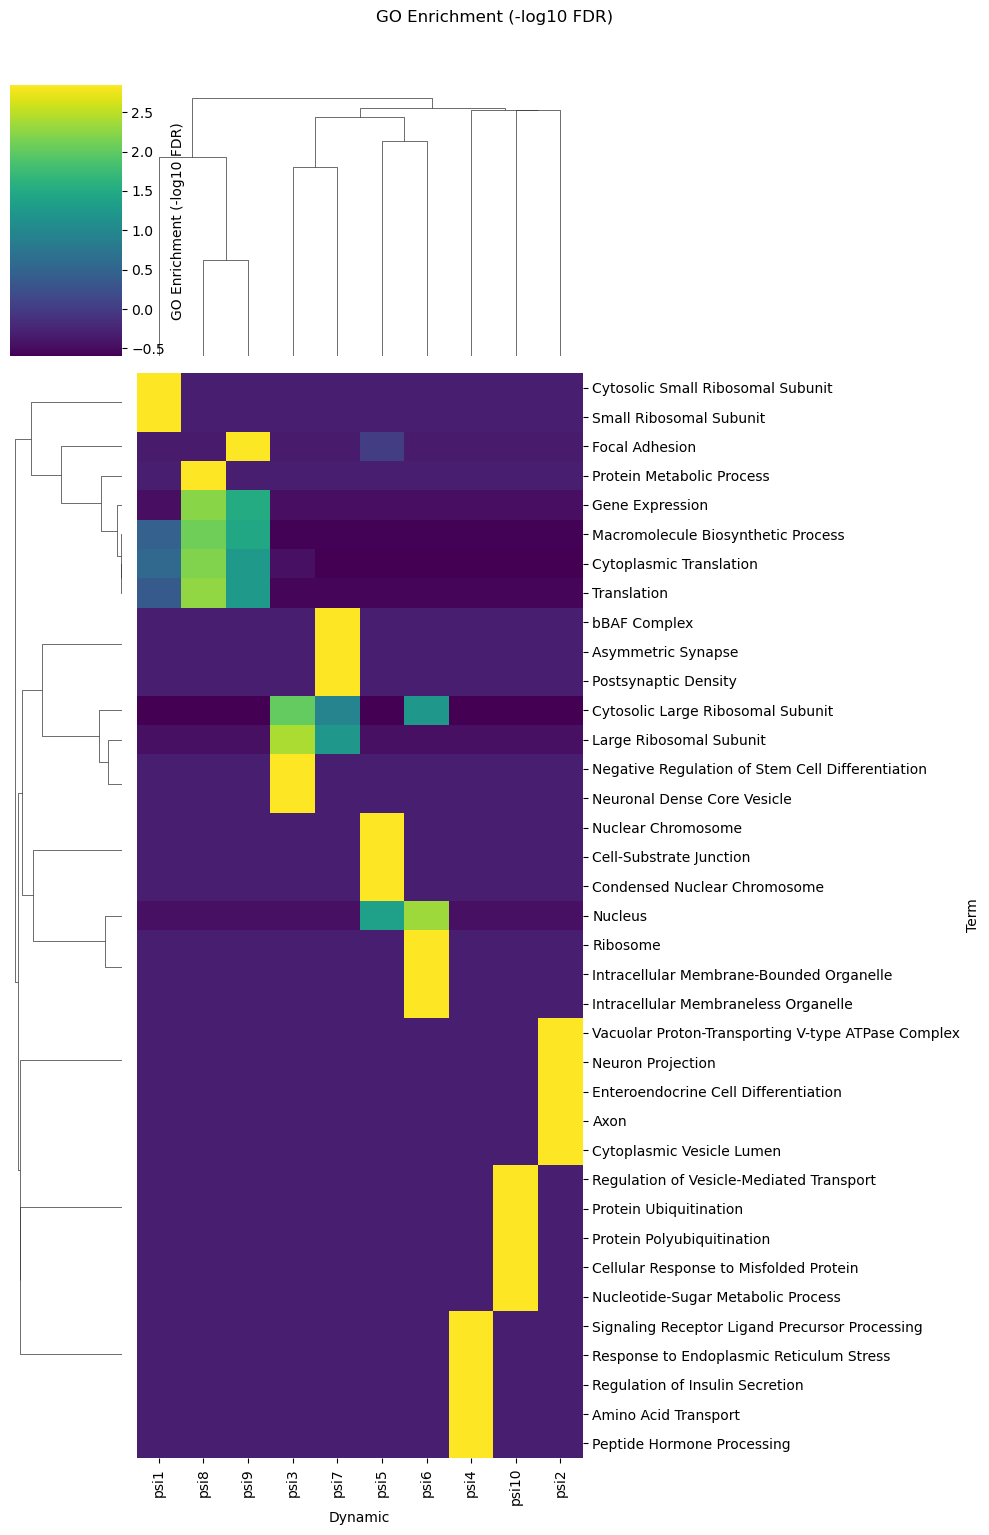

Saved: heatmap_neg.pdf


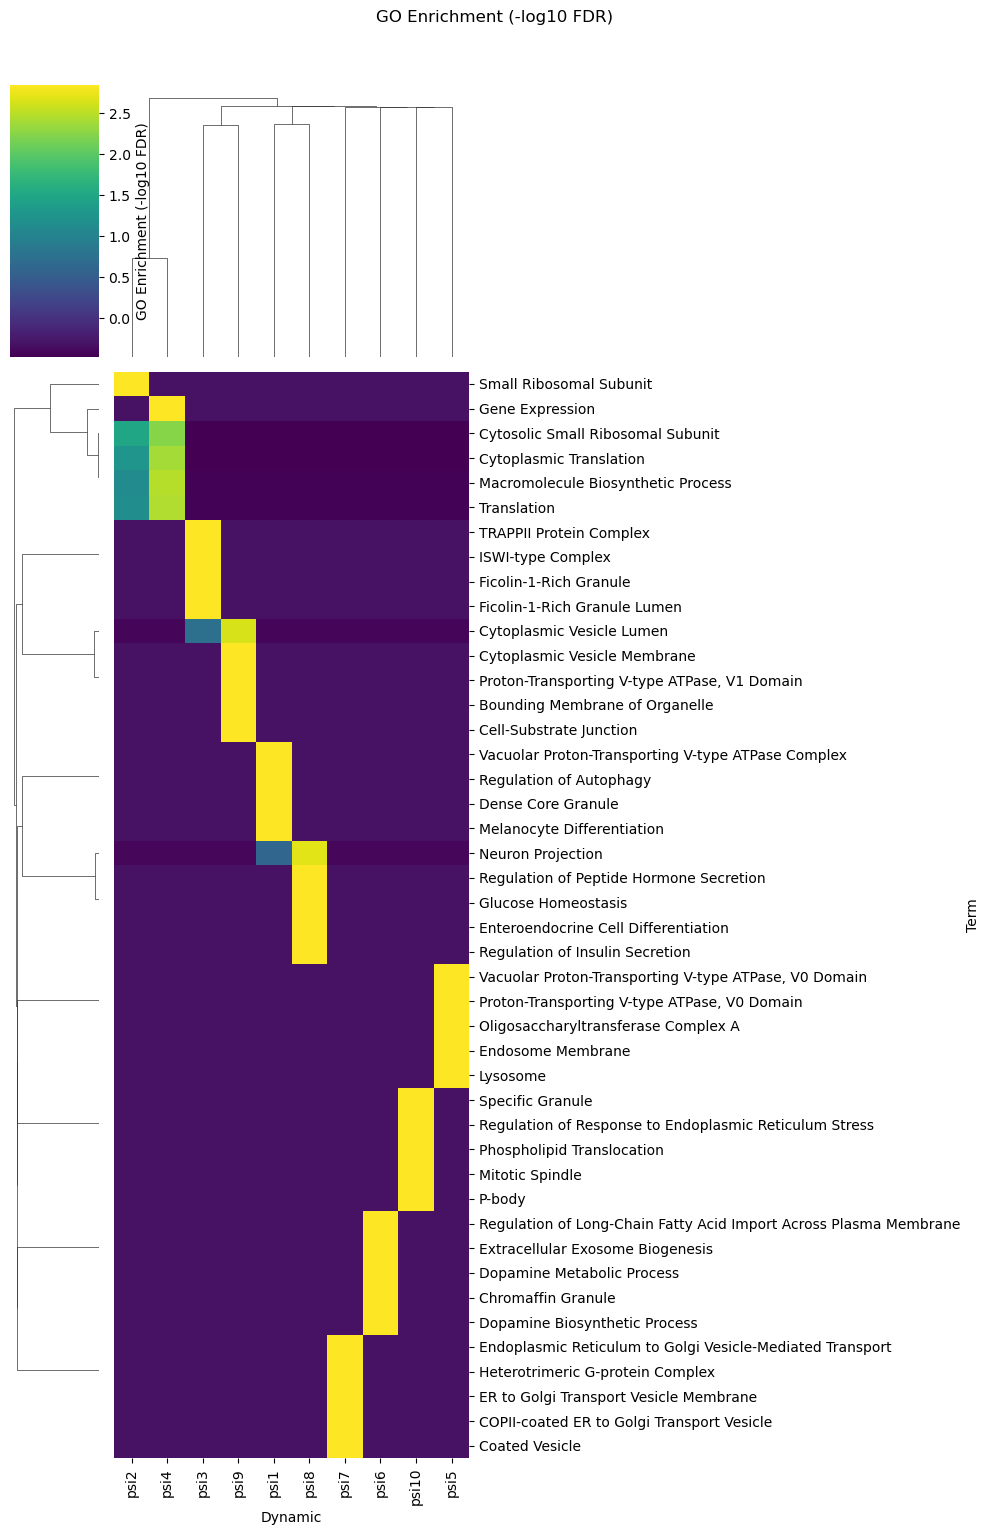

In [30]:
enrichment_results = run_enrichment(
    adata_VAPOR,
    select="both",
    top_n=200,
    organism="Mouse",
    gene_sets=("GO_Biological_Process_2025", "GO_Cellular_Component_2025"),
)

mat = build_heatmap_mats(enrichment_results, top_n=5)
for k, v in mat.items():
    plot_heatmap(v, 'GO Enrichment (-log10 FDR)',
                 figsize=(10, 15), cmap='viridis',
                 cluster=True, col_cluster=True, zscore_rows=True,
                 save=f"heatmap_{k}.pdf")